In [1]:
!pip install xee,rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.3 MB/s eta 0:00:00


In [144]:
import xee
import xarray as xr
import ee
import matplotlib.pyplot as plt
import numpy as np
import geemap
import rioxarray
import geopandas as gpd
import shapely.geometry

In [3]:
ee.Authenticate()

In [4]:
ee.Initialize(project = "ee-rahul20252027",opt_url = "https://earthengine-highvolume.googleapis.com")

In [9]:
Map = geemap.Map(Basemap = "Satellite")

Using ERA -5 Daily Air temperature above 2m from the surface data

In [37]:
temp = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")\
.filterDate('2024-01-01','2024-12-01')\
.select('temperature_2m')

The Imagecollection from GEE has now been exported as Xarray

In [38]:
ds = xr.open_dataset(temp, engine='ee', crs='EPSG:4326', scale=0.25)

Originally in Kelvin

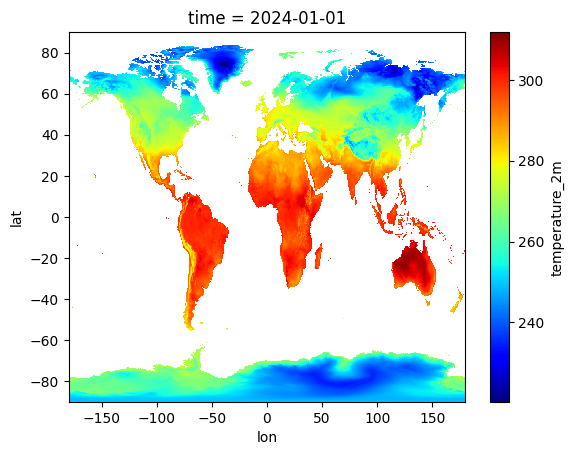

In [43]:
jan_data = ds.sel(time = '2024-01-01')
jan_data['temperature_2m'].plot(x = 'lon',y='lat',cmap = 'jet')

Converting to Celcius

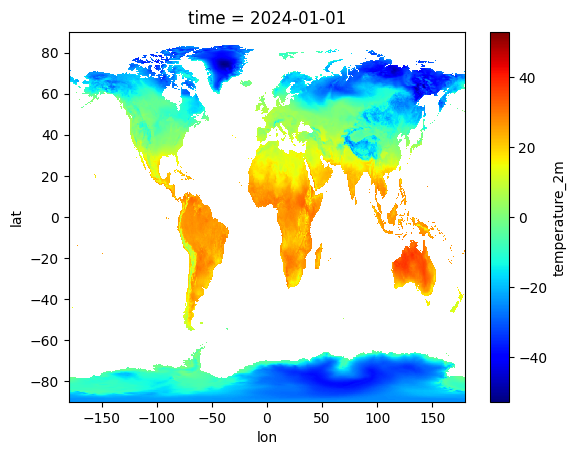

In [44]:
jan_data_cel = jan_data['temperature_2m'] - 273.15
jan_data_cel.plot(x = 'lon',y='lat',cmap = 'jet')

Aggregating daily data to weekly aggregates

In [45]:
ds_weekly = ds.resample(time = '7D').mean()
len(ds_weekly)

1

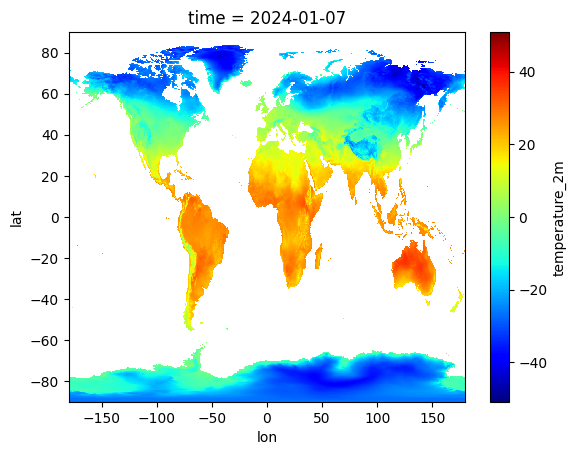

In [19]:
jan_week1 = ds_weekly.sel(time = '2024-01-07')
jan_week_cel = jan_week1['temperature_2m'] -273.15
jan_week_cel.plot(x = 'lon',y='lat',cmap = 'jet')

Plotting multiple data together

In [51]:
first_four_week = ds_weekly.isel(time = slice(0,4))

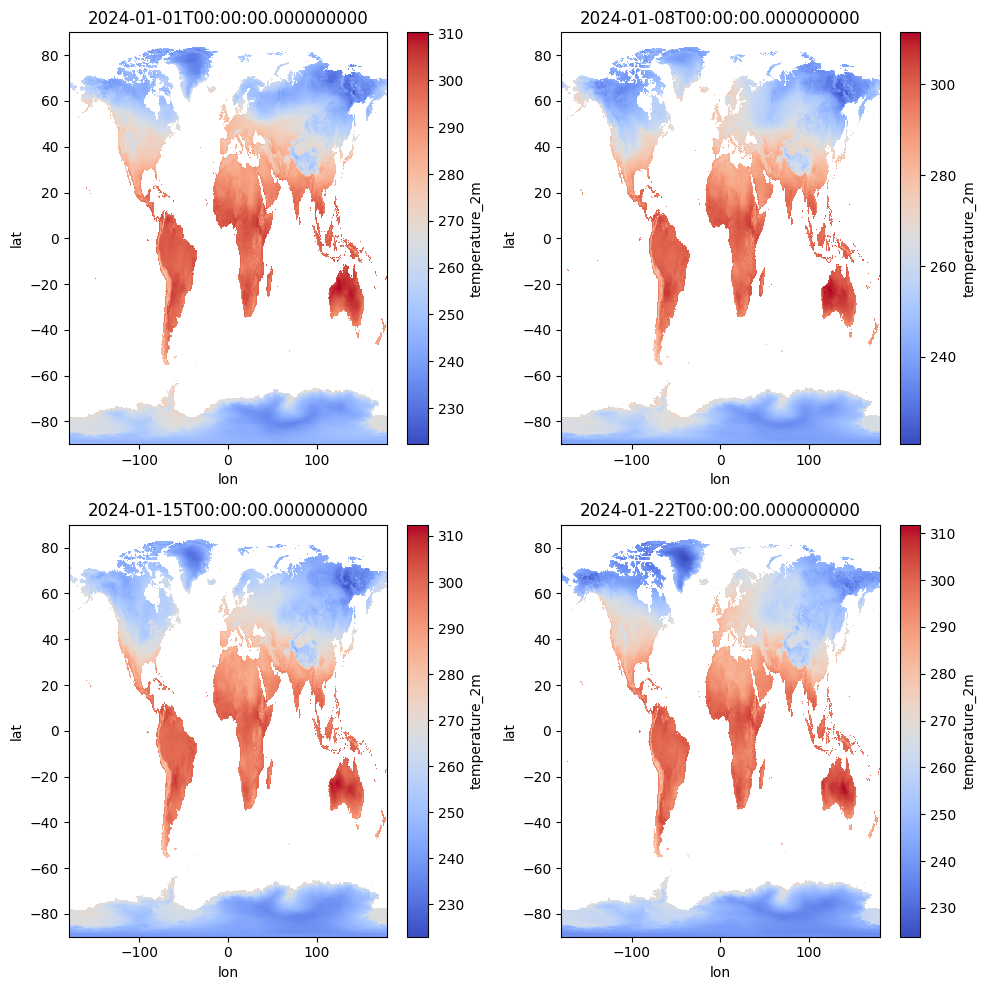

In [84]:

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i in range(len(first_four_week['time'])):
    first_four_week['temperature_2m'].isel(time=i).plot(
        ax=axes[i], cmap='coolwarm',
        x='lon', y='lat' )
    axes[i].set_title(str(first_four_week.time.values[i]))

plt.tight_layout()
plt.show()

Using Google Earth Engine API to do geospatial processing

Utilising the dynamic map to define a AOI

In [86]:
Map = geemap.Map(Basemap = "Satellite")
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

Converting the dynamic map into a Geodataframe

In [126]:
drawn_feature = Map.draw_features[-1]
region = ee.Geometry(drawn_feature.getInfo()['geometry'])  #geoJSON
gdf_shape = shapely.geometry.shape(region.getInfo())  #GEOJSON >>> POLYGON

gdf = gpd.GeoDataFrame({"geometry" : [gdf_shape]},crs ='EPSG:4326')


Lets clip using this generated Dataframe

In [142]:
data = ds['temperature_2m'].sel(time = '2024-01-08')
# data.plot(x = 'lon',y='lat',cmap = 'jet')
data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
clipped_ds = data.rio.clip(gdf.geometry,gdf.crs)

Final Nail!!! We have an air temperature map of India

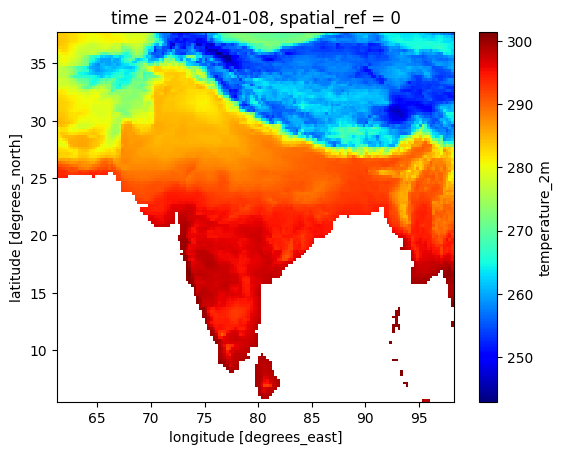

In [143]:
clipped_ds.plot(x = 'lon',y='lat',cmap = 'jet')